# M5 Exploratory Data Analysis

**Exploration only.** The production system lives in `src/demand_forecasting/`; this notebook exists to look at the data and justify design decisions (metric choices, intermittency handling, feature ideas). It reads the validated Parquet outputs of the data layer — run `python -m demand_forecasting.data.convert` first.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#dddddd", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.figsize": (9, 3.5),
})
GRAY = "#404040"

sales = pd.read_parquet("../data/processed/sales.parquet")
calendar = pd.read_parquet("../data/processed/calendar.parquet")
prices = pd.read_parquet("../data/processed/prices.parquet")
d_cols = [c for c in sales.columns if c.startswith("d_")]
print(f"sales: {sales.shape[0]:,} series x {len(d_cols):,} days")
print(f"calendar: {len(calendar):,} days | prices: {len(prices):,} rows")

Matplotlib is building the font cache; this may take a moment.


sales: 30,490 series x 1,941 days
calendar: 1,969 days | prices: 6,841,121 rows


## 1. The hierarchy

Every series sits inside a product hierarchy (item → department → category) crossed with a location hierarchy (store → state). Forecast accuracy must be reported at several of these levels — aggregate accuracy can hide item-level failure, and orders are placed at the item-store level.

state_id        3
store_id       10
cat_id          3
dept_id         7
item_id     3,049


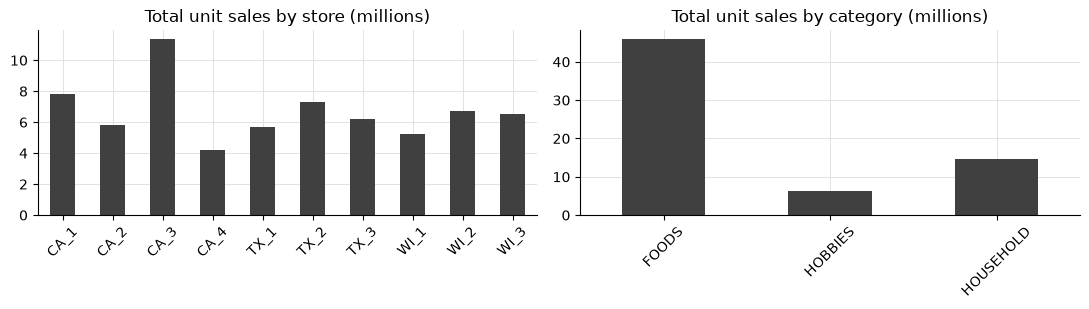

In [2]:
for level in ["state_id", "store_id", "cat_id", "dept_id", "item_id"]:
    print(f"{level:10s} {sales[level].nunique():>6,}")

totals = sales[d_cols].sum(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
totals.groupby(sales["store_id"], observed=True).sum().div(1e6).plot.bar(
    ax=axes[0], color=GRAY, title="Total unit sales by store (millions)")
totals.groupby(sales["cat_id"], observed=True).sum().div(1e6).plot.bar(
    ax=axes[1], color=GRAY, title="Total unit sales by category (millions)")
for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

## 2. Intermittency — the defining property of this data

A large share of item-store-days have **zero** sales. This single fact drives the metric choices: MAPE divides by actual sales and blows up on zero days, so the evaluation panel uses WAPE (volume-weighted), MASE (scaled against seasonal-naive) and WRMSSE (the official M5 metric) instead.

overall zero rate: 68.0%
series with >90% zero days: 16.8%


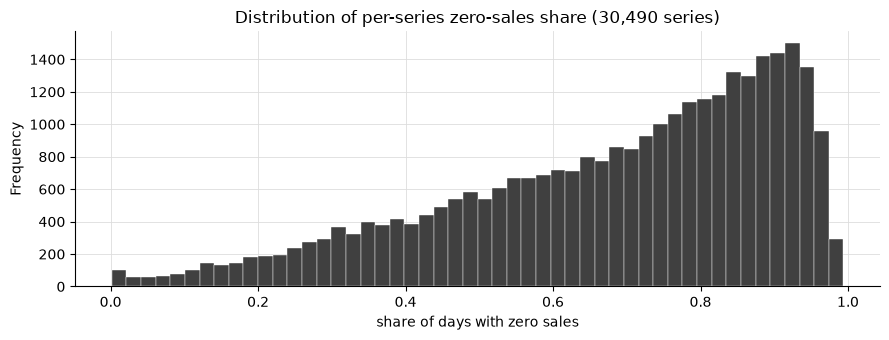

In [3]:
values = sales[d_cols]
zero_rate_per_series = (values == 0).mean(axis=1)
print(f"overall zero rate: {(values == 0).to_numpy().mean():.1%}")
print(f"series with >90% zero days: {(zero_rate_per_series > 0.9).mean():.1%}")

ax = zero_rate_per_series.plot.hist(bins=50, color=GRAY, edgecolor="white", linewidth=0.3)
ax.set_title("Distribution of per-series zero-sales share (30,490 series)")
ax.set_xlabel("share of days with zero sales")
plt.tight_layout()

## 3. Seasonality and trend

Total demand shows a slow upward trend, annual seasonality (dips at Christmas — the only day stores close), and a strong weekly cycle. This motivates the lag-7 / lag-28 features and the calendar features in the pipeline.

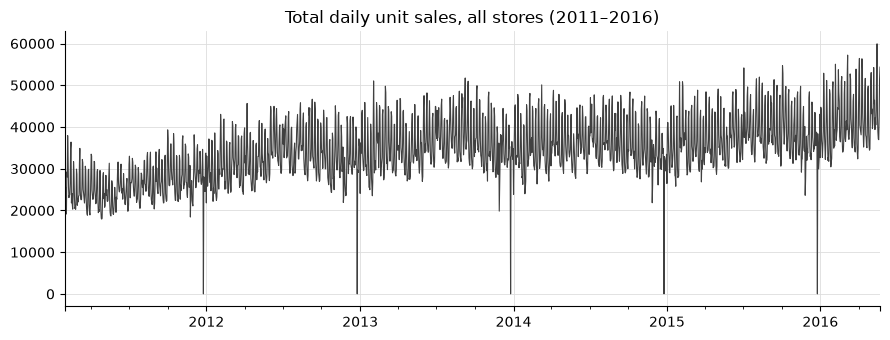

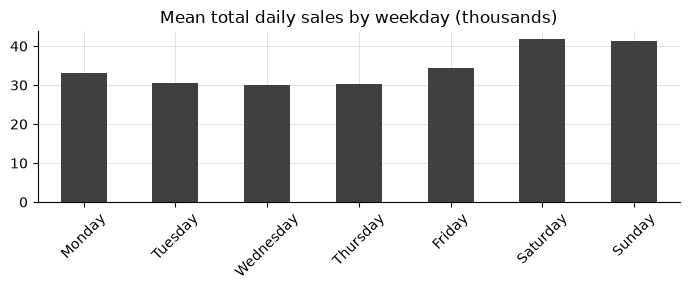

In [4]:
daily_total = pd.Series(values.sum(axis=0).to_numpy(), index=calendar["date"][:len(d_cols)])
ax = daily_total.plot(color=GRAY, linewidth=0.8)
ax.set_title("Total daily unit sales, all stores (2011–2016)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

weekday_mean = daily_total.groupby(calendar["weekday"][:len(d_cols)].to_numpy()).mean()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
ax = weekday_mean.reindex(order).div(1e3).plot.bar(color=GRAY, figsize=(7, 3))
ax.set_title("Mean total daily sales by weekday (thousands)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

## 4. SNAP days

SNAP (food-assistance) purchase days shift food demand within the month. The feature pipeline collapses the three state flags into a single `snap` flag matched to each row's own state.

In [5]:
foods_ca = sales[(sales["cat_id"] == "FOODS") & (sales["state_id"] == "CA")]
daily_foods_ca = foods_ca[d_cols].sum(axis=0).to_numpy()
snap_flag = calendar["snap_CA"][:len(d_cols)].to_numpy().astype(bool)
on, off = daily_foods_ca[snap_flag].mean(), daily_foods_ca[~snap_flag].mean()
print(f"CA FOODS mean daily sales — SNAP days: {on:,.0f} | non-SNAP: {off:,.0f} "
      f"| lift: {on / off - 1:+.1%}")

CA FOODS mean daily sales — SNAP days: 10,733 | non-SNAP: 9,736 | lift: +10.2%


## 5. Prices

Prices are weekly per item-store and only exist from an item's first listed week — the pipeline drops pre-release rows (~21% of the raw grid) rather than treating “not yet sold anywhere” as demand of zero.

In [6]:
changes = (
    prices.sort_values(["store_id", "item_id", "wm_yr_wk"])
    .groupby(["store_id", "item_id"], observed=True)["sell_price"]
    .pct_change(fill_method=None)
)
print(f"weeks with a price change: {(changes.fillna(0) != 0).mean():.1%}")
print(f"median |change| when it changes: {changes[changes != 0].abs().median():.1%}")

weeks with a price change: 1.2%
median |change| when it changes: 9.4%


## Takeaways → design decisions

| Observation | Decision it justifies |
|---|---|
| ~68% of item-days are zero sales; many series are >90% zeros | WAPE / MASE / WRMSSE instead of MAPE; quantile forecasts instead of points |
| 5 hierarchy levels from item-store (30,490) up to total | Evaluation panel reports per level, not one aggregate number |
| Strong weekly cycle + annual seasonality + trend | lag-7 / lag-28, rolling means, calendar features |
| SNAP days lift food demand measurably | per-state `snap` feature |
| Prices change in a minority of weeks but visibly | price level, week-over-week change, dept-relative price features |
| ~21% of the raw grid is pre-release | drop pre-release rows; cold-start handled explicitly at inference (M6) |